<a href="https://colab.research.google.com/github/Raghad770/NLP-Hands-on/blob/main/Multilingual_Named_Entity_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# zero-shot cross-lingual transfer



* The model is pre-trained on many languages together, so it learns to represent words and sentences from different languages in a shared way.

* Then it’s fine-tuned on a specific task (like classification) using labeled data from just one language.

* Because of the shared multilingual knowledge learned during pre-training, the model can apply what it learned to other languages—even without additional fine-tuning on those languages.

This is the core idea behind zero-shot cross-lingual transfer: the model generalizes from one language’s task data to other languages automatically.

1. Multilingual pre-training learns language-agnostic representations

    - Large multilingual models (like mBERT, XLM-R) are trained on massive text corpora from many languages at once.

    - They learn to represent words and sentences in a shared embedding space, where words with similar meanings from different languages have close or similar vector representations.

    - This works because many languages share underlying structures (e.g., syntax, semantics), and the model abstracts these universal features across languages.


2. Shared subword vocabularies

    - These models often use subword tokenization (e.g., WordPiece or SentencePiece) that breaks words into smaller units shared across languages.

    - This sharing allows the model to decompose and recognize parts of words even for languages it hasn’t explicitly trained on for a task.


3. Generalization from source to target languages

    - When fine-tuned on a specific task in one language, the model adapts to patterns and representations useful for the task but at a level abstract enough to apply across languages.

    - For example, classification rules learned on English sentiment can transfer reasonably because the model’s representations capture meaning rather than just surface forms.


# Dataset

In [1]:
from datasets import get_dataset_config_names

xtreme_subsets = get_dataset_config_names("xtreme")
print(f"XTREME has {len(xtreme_subsets)} configurations")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

XTREME has 183 configurations


In [2]:
from datasets import load_dataset

data=load_dataset("xtreme", name="PAN-X.de")

PAN-X.de/train-00000-of-00001.parquet:   0%|          | 0.00/1.18M [00:00<?, ?B/s]

PAN-X.de/validation-00000-of-00001.parqu(…):   0%|          | 0.00/590k [00:00<?, ?B/s]

PAN-X.de/test-00000-of-00001.parquet:   0%|          | 0.00/588k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [3]:
for split in data:
  print(split)

train
validation
test


To make a realistic Swiss corpus, we’ll sample the German (de), French (fr), Italian (it), and English (en) corpora from PAN-X according to their spoken proportions. This will create a language imbalance that is very common in real-world datasets

In [4]:
from typing_extensions import DefaultDict
from collections import defaultdict
from datasets import DatasetDict

langs = ["de","fr","it","en"]
fracs = [0.629, 0.229, 0.084, 0.059]

panx_ch = DefaultDict(DatasetDict)
for lang, frac in zip(langs,fracs):
  ds = load_dataset("xtreme", name=f"PAN-X.{lang}")
  for split in ds:
    panx_ch[lang][split]=(ds[split]
                          .shuffle(seed=0)
                          .select(range(int(frac*ds[split].num_rows))))

PAN-X.fr/train-00000-of-00001.parquet:   0%|          | 0.00/837k [00:00<?, ?B/s]

PAN-X.fr/validation-00000-of-00001.parqu(…):   0%|          | 0.00/419k [00:00<?, ?B/s]

PAN-X.fr/test-00000-of-00001.parquet:   0%|          | 0.00/423k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

...

PAN-X.en/validation-00000-of-00001.parqu(…):   0%|          | 0.00/472k [00:00<?, ?B/s]

PAN-X.en/test-00000-of-00001.parquet:   0%|          | 0.00/472k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Here we’ve used the shuffle() method to make sure we don’t accidentally bias our dataset splits, while select() allows us to downsample each corpus according to the values in fracs.

In [5]:
panx_ch

defaultdict(datasets.dataset_dict.DatasetDict,
            {'de': DatasetDict({
                 train: Dataset({
                     features: ['tokens', 'ner_tags', 'langs'],
                     num_rows: 12580
                 })
                 validation: Dataset({
                     features: ['tokens', 'ner_tags', 'langs'],
                     num_rows: 6290
                 })
                 test: Dataset({
                     features: ['tokens', 'ner_tags', 'langs'],
                     num_rows: 6290
                 })
             }),
             'fr': DatasetDict({
                 train: Dataset({
                     features: ['tokens', 'ner_tags', 'langs'],
                     num_rows: 4580
                 })
                 validation: Dataset({
                     features: ['tokens', 'ner_tags', 'langs'],
                     num_rows: 2290
                 })
                 test: Dataset({
                     features: ['tokens', 'ner_tags', 'la

In [6]:
element = panx_ch["de"]["train"][0]

In [7]:
len(element.items())

3

In [8]:
for key, value in element.items():
  print(f"{key}: {value}")

tokens: ['2.000', 'Einwohnern', 'an', 'der', 'Danziger', 'Bucht', 'in', 'der', 'polnischen', 'Woiwodschaft', 'Pommern', '.']
ner_tags: [0, 0, 0, 0, 5, 6, 0, 0, 5, 5, 6, 0]
langs: ['de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de']


In [9]:
for key, value in panx_ch["de"]["train"].features.items():
    print(f"{key}: {value}")

tokens: List(Value('string'))
ner_tags: List(ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']))
langs: List(Value('string'))


In [10]:
tags = panx_ch["de"]["train"].features["ner_tags"].feature
print(tags)

ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'])


In [11]:
def create_tag_names(batch):
  tag_names = []
  for tag in batch['ner_tags']:
    curr_tag = tags.int2str(tag)
    tag_names.append(curr_tag)
  return {"tag_names":tag_names}
  # print(tag_names)



In [12]:
def create_tag_names(batch):
    return {"ner_tags_str": [tags.int2str(idx) for idx in batch["ner_tags"]]}

# panx_de = panx_ch["de"].map(create_tag_names)

if you applying this to entire dataset you do that:

In [13]:
panx_de = panx_ch['de'].map(create_tag_names)

Map:   0%|          | 0/12580 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

In [14]:
panx_de.items()

dict_items([('train', Dataset({
    features: ['tokens', 'ner_tags', 'langs', 'ner_tags_str'],
    num_rows: 12580
})), ('validation', Dataset({
    features: ['tokens', 'ner_tags', 'langs', 'ner_tags_str'],
    num_rows: 6290
})), ('test', Dataset({
    features: ['tokens', 'ner_tags', 'langs', 'ner_tags_str'],
    num_rows: 6290
}))])

In [15]:
import pandas as pd
pd.DataFrame(panx_de['train'][0])

,tokens,ner_tags,langs,ner_tags_str
0,2.000,0,de,O
1,Einwohnern,0,de,O
2,an,0,de,O
3,der,0,de,O
4,Danziger,5,de,B-LOC
5,Bucht,6,de,I-LOC
6,in,0,de,O
7,der,0,de,O
8,polnischen,5,de,B-LOC
9,Woiwodschaft,5,de,B-LOC


As a quick check that we don’t have any unusual imbalance in the tags, let’s calculate the frequencies of each entity across each split:

In [16]:
from collections import Counter

split2freqs = defaultdict(Counter)
for split, dataset in panx_de.items():
    for row in dataset["ner_tags_str"]:
        for tag in row:
            if tag.startswith("B"):
                tag_type = tag.split("-")[1]
                split2freqs[split][tag_type] += 1
pd.DataFrame.from_dict(split2freqs, orient="index")

,LOC,ORG,PER
train,6186,5366,5810
validation,3172,2683,2893
test,3180,2573,3071


he purpose of that code is **to check entity frequency distribution (how many PER/ORG/LOC entities exist in each split)**, not how many tokens are tagged.

- By counting only `B-`, you ensure each entity is counted **once**, regardless of its length.

# Multilingual Transformers


### 🔹 RoBERTa

- It’s an improved version of **BERT** (a famous language model).
- The creators made it better by:
    - **Removing the “next sentence prediction” task** (BERT used it, but it turned out not to help much).
    - Training longer, on more data, with bigger batches.

---

### 🔹 XLM-R (XLM-RoBERTa)

- Basically a **multilingual version of RoBERTa**.
- Differences:
    1. **No language embeddings** → the model doesn’t get an extra signal like “this is English” or “this is French.”
    2. **Uses SentencePiece** → a tool that breaks raw text into smaller pieces (subwords) without needing language-specific rules.
    3. **Much larger vocabulary** →
        - RoBERTa: \~55,000 tokens (subwords).
        - XLM-R: \~250,000 tokens (so it can cover many languages at once).

Instead of using a WordPiece tokenizer, XLM-R uses a tokenizer called SentencePiece that is trained on the raw text of all one hundred languages

In [17]:
from transformers import AutoTokenizer
bert_model_name = "bert-base-cased"
xlmr_model_name = "xlm-roberta-base"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
xlmr_tokenizer = AutoTokenizer.from_pretrained(xlmr_model_name)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [18]:
text = "Jack Sparrow loves New York!"
bert_tokens = bert_tokenizer(text).tokens()
xlmr_tokens = xlmr_tokenizer(text).tokens()
print(f"BERT tokens: {bert_tokens}")
print(f"XLM-R tokens: {xlmr_tokens}")

BERT tokens: ['[CLS]', 'Jack', 'Spa', '##rrow', 'loves', 'New', 'York', '!', '[SEP]']
XLM-R tokens: ['<s>', '▁Jack', '▁Spar', 'row', '▁love', 's', '▁New', '▁York', '!', '</s>']


The sentencepiece tokenizer:

* is based on a type of subword segmentation called unigram and encodes each input text as a sequence of unicode charcters.

* this last feature is especially useful for multilingual corpora since it allows sentencepiece to be agnostic about accents, punctuation and the fact that many languanges like Japanese, do not have whitespace characters.

* Another special feature of SentencePiece is that whitespace is assigned the Unicode symbol U+2581, or the ▁ character, This enables SentencePiece to detokenize a sequence without ambiguities and without relying on language-specific pretokenizers.


In [19]:
"".join(xlmr_tokens).replace(u"\u2581", " ")

'<s> Jack Sparrow loves New York!</s>'

#Creating a Custom Model for Token Classification


**NER** >> is ofter framed as **token classification** because that the representation of each individual input token is fed into the same fully connected layer to  output the entity of the token in the opposit in cls probelm


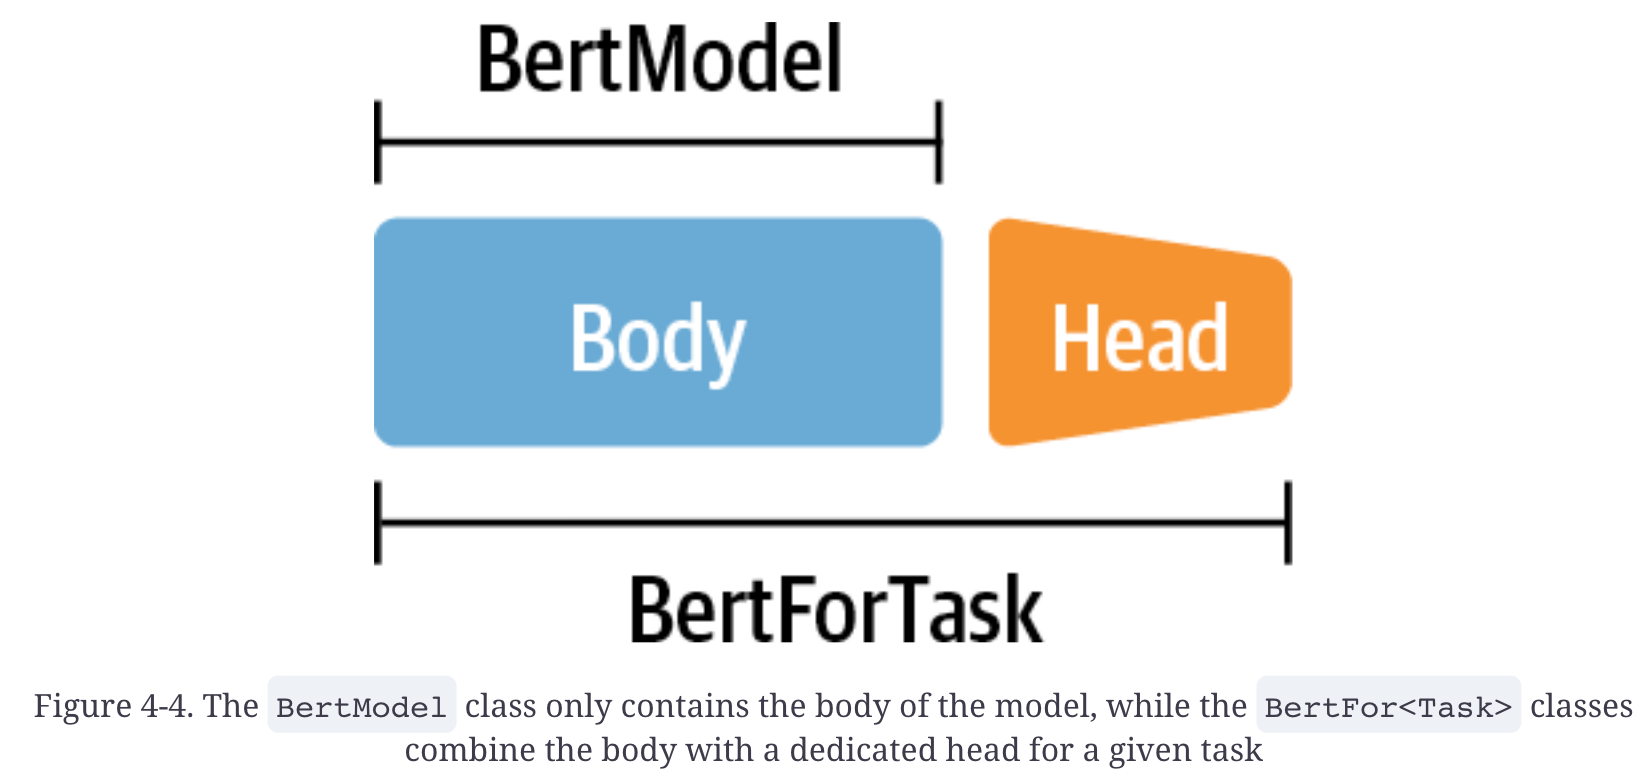

the body; it includes the token embeddings and transformer layers that are task-agnostic. This structure is reflected in the nlpt_pin01 Transformers code as well: the body of a model is implemented in a class such as BertModel or GPT2Model that returns the hidden states of the last layer. Task-specific models such as BertForMaskedLM or BertForSequenceClassification use the base model and add the necessary head on top of the hidden states,

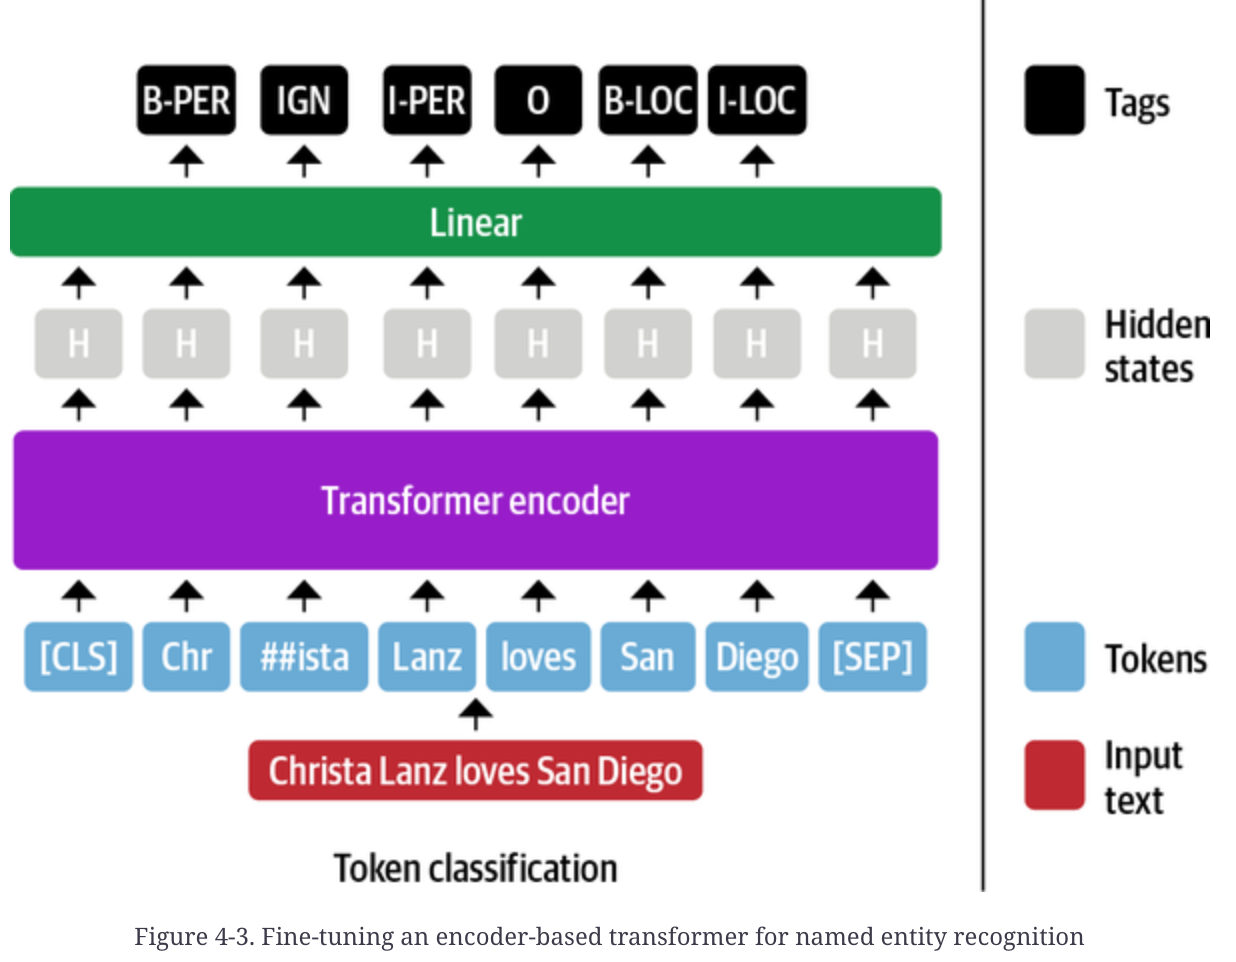

build a custom model for your own task. For token classification, an **XLMRobertaForTokenClassification**

In [20]:
import torch.nn as nn
from transformers import XLMRobertaConfig
from transformers.modeling_outputs import TokenClassifierOutput
from transformers.models.roberta.modeling_roberta import RobertaModel
from transformers.models.roberta.modeling_roberta import RobertaPreTrainedModel

class XLMRobertaForTokenClassification(RobertaPreTrainedModel):
    config_class = XLMRobertaConfig
    print("XLMRoberta Config ",config_class)

    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        # Load model body
        self.roberta = RobertaModel(config, add_pooling_layer=False)
        # Set up token classification head
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)
        # Load and initialize weights
        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None,
                labels=None, **kwargs):
        # Use model body to get encoder representations
        outputs = self.roberta(input_ids, attention_mask=attention_mask,
                               token_type_ids=token_type_ids, **kwargs)
        # Apply classifier to encoder representation
        sequence_output = self.dropout(outputs[0])
        logits = self.classifier(sequence_output)
        # Calculate losses
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
        # Return model output object
        return TokenClassifierOutput(loss=loss, logits=logits,
                                     hidden_states=outputs.hidden_states,
                                     attentions=outputs.attentions)

XLMRoberta Config  <class 'transformers.models.xlm_roberta.configuration_xlm_roberta.XLMRobertaConfig'>


 * Note that we set add_​pool⁠ing_layer=False to ensure all hidden states are returned and not only the one associated with the [CLS] token.

 * Finally, we initialize all the weights by calling the init_weights() method we inherit from RobertaPreTrainedModel, which will load the pretrained weights for the model body and randomly initialize the weights of our token classification head.

Why is the output size of the linear layer the number of labels, not the number of tokens?

    self.classifier = nn.Linear(config.hidden_size, config.num_labels)

    The classifier works per token.
    For each token’s hidden vector, it predicts which label/category it belongs to (e.g., PERSON, LOCATION, etc.).

    So, for each token, you want a vector of size num_labels:

        If you have 7 label types, the output scores for a single token are length 7.




    The attention mask is a vector (or tensor) with length equal to the sequence length (number of tokens).

    It contains 1s for tokens that are real and should be attended to.

    It contains 0s for tokens that are padding—these tokens are not meaningful and should be ignored during attention computations.

    This mask helps the model focus only on valid tokens and avoid considering padded tokens when computing attention scores and outputs.


In [21]:
index2tag = {idx: tag for idx, tag in enumerate(tags.names)}
tag2index = {tag: idx for idx, tag in enumerate(tags.names)}

These mappings help convert back and forth between model outputs and human-readable labels.

In [22]:
index2tag

{0: 'O',
 1: 'B-PER',
 2: 'I-PER',
 3: 'B-ORG',
 4: 'I-ORG',
 5: 'B-LOC',
 6: 'I-LOC'}

In [23]:
tag2index

{'O': 0,
 'B-PER': 1,
 'I-PER': 2,
 'B-ORG': 3,
 'I-ORG': 4,
 'B-LOC': 5,
 'I-LOC': 6}

In [24]:
tags.names

['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']

In [25]:
from transformers import AutoConfig

xlmr_config = AutoConfig.from_pretrained(xlmr_model_name,
                                         num_labels=tags.num_classes,
                                         id2label=index2tag, label2id=tag2index)


Passing keyword arguments to the from_pretrained() method overrides the default values

The AutoConfig class contains the blueprint of a model’s architecture. When we load a model with AutoModel.from_pretrained(model_ckpt), the configuration file associated with that model is downloaded automatically. However, if we want to modify something like the number of classes or label names, then we can load the configuration first with the parameters we would like to customize.|

In [26]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
xlmr_model = (XLMRobertaForTokenClassification
              .from_pretrained(xlmr_model_name, config=xlmr_config)
              .to(device))

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [27]:
input_ids = xlmr_tokenizer.encode(text, return_tensors="pt")
pd.DataFrame([xlmr_tokens, input_ids[0].numpy()], index=["Tokens", "Input IDs"])

,0,1,2,3,4,5,6,7,8,9
Tokens,<s>,▁Jack,▁Spar,row,▁love,s,▁New,▁York,!,</s>
Input IDs,0,21763,37456,15555,5161,7,2356,5753,38,2


In [28]:
outputs = xlmr_model(input_ids.to(device)).logits
predictions = torch.argmax(outputs, dim=-1)
print(f"Number of tokens in sequence: {len(xlmr_tokens)}")
print(f"Shape of outputs: {outputs.shape}")

Number of tokens in sequence: 10
Shape of outputs: torch.Size([1, 10, 7])


In [29]:
print(outputs)

tensor([[[-0.1319,  0.2618, -0.3757,  0.0251, -0.2860,  0.0124, -0.0106],
         [-0.3128,  0.1444, -0.0859, -0.2488,  0.1473,  0.2985,  0.1189],
         [-0.1688,  0.2423, -0.1757, -0.0839,  0.0559,  0.3091,  0.0703],
         [-0.2753,  0.2416, -0.0760, -0.2048,  0.1566,  0.2645,  0.0687],
         [-0.2225,  0.1698, -0.1731, -0.0680,  0.2202,  0.2666,  0.0862],
         [-0.2480,  0.1752, -0.1988, -0.1317,  0.0137,  0.3092,  0.1147],
         [-0.2530,  0.1740, -0.1072, -0.1498,  0.0692,  0.3110,  0.0425],
         [-0.2548,  0.2347, -0.0504, -0.2512,  0.1406,  0.2899,  0.0897],
         [-0.1757,  0.1432, -0.0995, -0.2054,  0.0764,  0.2713, -0.0012],
         [-0.0357,  0.2729, -0.3064,  0.0332, -0.2474, -0.0403,  0.0452]]],
       device='cuda:0', grad_fn=<ViewBackward0>)


In [30]:
preds = [tags.names[p] for p in predictions[0].cpu().numpy()]

# Tokinze and FineTune the XLM-R model for NER

In [31]:
def tag_text(text, tags, model, tokenizer):
    # Get tokens with special characters
    tokens = tokenizer(text).tokens()
    # Encode the sequence into IDs
    input_ids = xlmr_tokenizer(text, return_tensors="pt").input_ids.to(device)
    # Get predictions as distribution over 7 possible classes
    outputs = model(input_ids)[0]
    # Take argmax to get most likely class per token
    predictions = torch.argmax(outputs, dim=2)
    # Convert to DataFrame
    preds = [tags.names[p] for p in predictions[0].cpu().numpy()]
    return pd.DataFrame([tokens, preds], index=["Tokens", "Tags"])

we’ve established that the tokenizer and model can encode a single example, our next step is to tokenize the whole dataset so that we can pass it to the XLM-R model for fine-tuning.

Since the XLM-R tokenizer returns the input IDs for the model’s inputs, we just need to augment this information with the attention mask and the label IDs that encode the information about which token is associated with each NER tag.

In [32]:
de_example = panx_de["train"][:10]

In [33]:
words, labels = de_example["tokens"], de_example["ner_tags"]


In [34]:
print(words)
print(labels)

[['2.000', 'Einwohnern', 'an', 'der', 'Danziger', 'Bucht', 'in', 'der', 'polnischen', 'Woiwodschaft', 'Pommern', '.'], ['Sie', 'geht', 'hinter', 'Walluf', 'nahtlos', 'in', 'die', 'Bundesautobahn', '66', 'über', '.'], ['Dirigenten', 'von', 'Weltruf', 'wie', 'Wilhelm', 'Furtwängler', ',', 'Erich', 'Kleiber', ',', 'Wolfgang', 'Sawallisch', ',', 'Karl', 'Böhm', ',', 'Herbert', 'von', 'Karajan', ',', 'Rafael', 'Kubelík', ',', 'Erich', 'Kleiber', ',', 'Bernard', 'Haitink', ',', 'Josef', 'Krips', ',', 'Zubin', 'Mehta', ',', 'Dimitri', 'Mitropoulos', ',', 'Antal', 'Doráti', ',', 'Sergiu', 'Celibidache', 'und', 'andere', 'haben', 'seine', 'Werke', 'dirigiert', ',', 'zuletzt', 'besonders', 'Horst', 'Stein', '.'], ["'", "''", 'Stade', 'Reims', "''", "'"], ['2011', 'David', 'J.', 'P.', 'Barker'], ['Sie', 'liegt', 'in', 'der', 'Metropolregion', 'Chicago', ',', 'rund', '40', 'km', 'westlich', 'der', 'Innenstadt', 'von', 'Chicago', '.'], ['Anschließend', 'wurde', 'er', 'ins', 'KZ', 'Sachsenhausen', '

In [35]:
tokenized_input = xlmr_tokenizer(de_example["tokens"], is_split_into_words=True)
tokens = xlmr_tokenizer.convert_ids_to_tokens(tokenized_input["input_ids"][0])
pd.DataFrame([tokens], index=["Tokens"])

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Tokens,<s>,▁2.000,▁Einwohner,n,▁an,▁der,▁Dan,zi,ger,▁Buch,...,▁Wo,i,wod,schaft,▁Po,mmer,n,▁,.,</s>


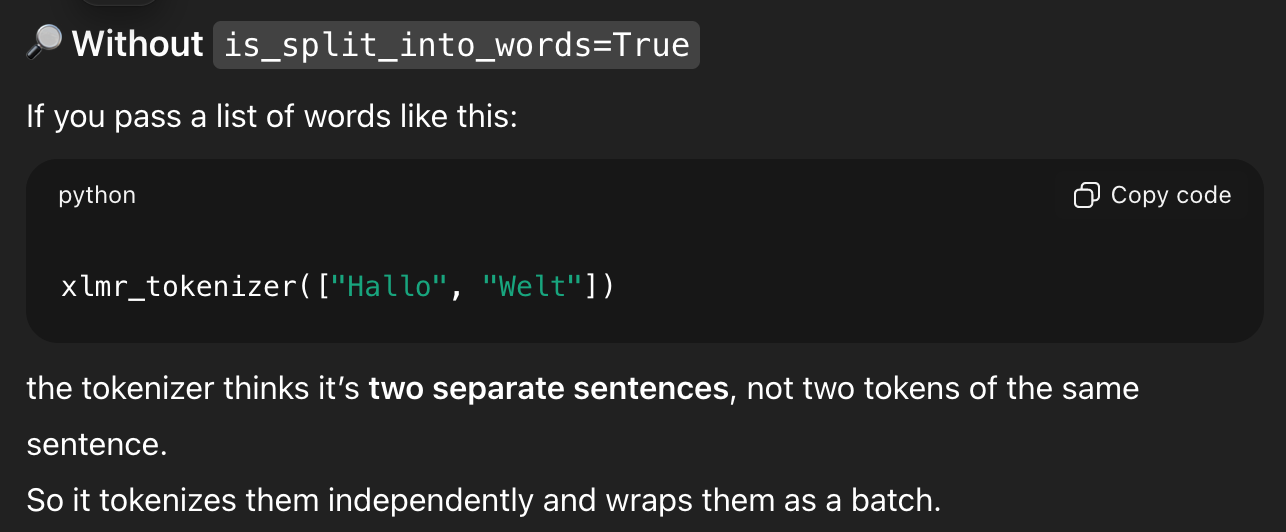

In [36]:
tokenized_input

{'input_ids': [[0, 70101, 176581, 19, 142, 122, 2290, 708, 1505, 18363, 18, 23, 122, 127474, 15439, 13787, 14, 15263, 18917, 663, 6947, 19, 6, 5, 2], [0, 727, 8644, 39119, 23706, 20101, 24, 9703, 2400, 23, 68, 23513, 8913, 64658, 11251, 1659, 6, 5, 2], [0, 230978, 33, 542, 12389, 47323, 1225, 96513, 27766, 32290, 20954, 603, 6, 4, 1004, 5548, 24798, 14, 1297, 6, 4, 149207, 947, 66769, 9370, 6, 4, 17038, 63068, 18337, 6, 4, 177592, 542, 9006, 2864, 6, 4, 63931, 1461, 372, 25555, 6, 4, 1004, 5548, 24798, 14, 1297, 6, 4, 56159, 4368, 2311, 92, 6, 4, 57995, 24315, 6423, 6, 4, 104763, 73, 30191, 102, 6, 4, 186340, 1208, 29813, 796, 2400, 6, 4, 78496, 984, 1680, 118, 6, 4, 125551, 34, 10077, 14, 40578, 1430, 165, 4052, 2028, 10810, 34371, 13, 98086, 2529, 6, 4, 118490, 30373, 7974, 271, 27822, 6, 5, 2], [0, 242, 5106, 46231, 13, 20130, 4432, 5106, 242, 2], [0, 1392, 6765, 821, 5, 436, 5, 3253, 1728, 2], [0, 727, 20267, 23, 122, 117366, 80938, 58823, 6, 4, 12711, 1112, 1785, 65272, 5486, 122,

we can see that the tokenizer has split “Einwohnern” into two subwords, “▁Einwohner” and “n”. Since we’re following the convention that only “▁Einwohner” should be associated with the B-LOC label, we need a way to mask the subword representations after the first subword.

Fortunately, tokenized_input is a class that contains a word_ids() function that can help us achieve this:

In [37]:
word_ids = tokenized_input.word_ids()
pd.DataFrame([tokens, word_ids],index = ["Tokens", "Word IDs"])

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Tokens,<s>,▁2.000,▁Einwohner,n,▁an,▁der,▁Dan,zi,ger,▁Buch,...,▁Wo,i,wod,schaft,▁Po,mmer,n,▁,.,</s>
Word IDs,None,0,1,1,2,3,4,4,4,5,...,9,9,9,9,10,10,10,11,11,None


In [38]:
words[0]

['2.000',
 'Einwohnern',
 'an',
 'der',
 'Danziger',
 'Bucht',
 'in',
 'der',
 'polnischen',
 'Woiwodschaft',
 'Pommern',
 '.']

In [39]:
labels[0]

[0, 0, 0, 0, 5, 6, 0, 0, 5, 5, 6, 0]

In [40]:
previous_word_ids = None
label_ids=[]

for word_idx in word_ids:
  print(word_idx)
  if word_idx is None or word_idx == previous_word_ids:
    label_ids.append(-100)
  elif word_idx != previous_word_ids:
    label_ids.append(labels[0][word_idx])
  print(label_ids)
  previous_word_ids = word_idx

None
[-100]
0
[-100, 0]
1
[-100, 0, 0]
1
[-100, 0, 0, -100]
2
[-100, 0, 0, -100, 0]
3
[-100, 0, 0, -100, 0, 0]
4
[-100, 0, 0, -100, 0, 0, 5]
4
[-100, 0, 0, -100, 0, 0, 5, -100]
4
[-100, 0, 0, -100, 0, 0, 5, -100, -100]
5
[-100, 0, 0, -100, 0, 0, 5, -100, -100, 6]
5
[-100, 0, 0, -100, 0, 0, 5, -100, -100, 6, -100]
6
[-100, 0, 0, -100, 0, 0, 5, -100, -100, 6, -100, 0]
7
[-100, 0, 0, -100, 0, 0, 5, -100, -100, 6, -100, 0, 0]
8
[-100, 0, 0, -100, 0, 0, 5, -100, -100, 6, -100, 0, 0, 5]
8
[-100, 0, 0, -100, 0, 0, 5, -100, -100, 6, -100, 0, 0, 5, -100]
9
[-100, 0, 0, -100, 0, 0, 5, -100, -100, 6, -100, 0, 0, 5, -100, 5]
9
[-100, 0, 0, -100, 0, 0, 5, -100, -100, 6, -100, 0, 0, 5, -100, 5, -100]
9
[-100, 0, 0, -100, 0, 0, 5, -100, -100, 6, -100, 0, 0, 5, -100, 5, -100, -100]
9
[-100, 0, 0, -100, 0, 0, 5, -100, -100, 6, -100, 0, 0, 5, -100, 5, -100, -100, -100]
10
[-100, 0, 0, -100, 0, 0, 5, -100, -100, 6, -100, 0, 0, 5, -100, 5, -100, -100, -100, 6]
10
[-100, 0, 0, -100, 0, 0, 5, -100, -100, 6,

In [41]:
labels = [index2tag[l] if l != -100 else "IGN" for l in label_ids]
index = ["Tokens", "Word IDs", "Label IDs", "Labels"]

pd.DataFrame([tokens, word_ids, label_ids, labels], index=index)

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Tokens,<s>,▁2.000,▁Einwohner,n,▁an,▁der,▁Dan,zi,ger,▁Buch,...,▁Wo,i,wod,schaft,▁Po,mmer,n,▁,.,</s>
Word IDs,None,0,1,1,2,3,4,4,4,5,...,9,9,9,9,10,10,10,11,11,None
Label IDs,-100,0,0,-100,0,0,5,-100,-100,6,...,5,-100,-100,-100,6,-100,-100,0,-100,-100
Labels,IGN,O,O,IGN,O,O,B-LOC,IGN,IGN,I-LOC,...,B-LOC,IGN,IGN,IGN,I-LOC,IGN,IGN,O,IGN,IGN


Why did we choose –100 as the ID to mask subword representations? The reason is that in PyTorch the cross-entropy loss class torch.nn.CrossEntropyLoss has an attribute called ignore_index whose value is –100. This index is ignored during training, so we can use it to ignore the tokens associated with consecutive subwords.

In [42]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = xlmr_tokenizer(examples["tokens"], truncation=True,
                                      is_split_into_words=True)
    labels = []
    for idx, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=idx)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None or word_idx == previous_word_idx:
                label_ids.append(-100)
            else:
                label_ids.append(label[word_idx])
            previous_word_idx = word_idx
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [43]:
def encode_panx_dataset(corpus):
    return corpus.map(tokenize_and_align_labels, batched=True,
                      remove_columns=['langs', 'ner_tags', 'tokens'])

In [44]:
panx_de_encoded = encode_panx_dataset(panx_ch["de"])


Map:   0%|          | 0/12580 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

In [45]:
panx_de_encoded["train"][0]

{'input_ids': [0,
  70101,
  176581,
  19,
  142,
  122,
  2290,
  708,
  1505,
  18363,
  18,
  23,
  122,
  127474,
  15439,
  13787,
  14,
  15263,
  18917,
  663,
  6947,
  19,
  6,
  5,
  2],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1],
 'labels': [-100,
  0,
  0,
  -100,
  0,
  0,
  5,
  -100,
  -100,
  6,
  -100,
  0,
  0,
  5,
  -100,
  5,
  -100,
  -100,
  -100,
  6,
  -100,
  -100,
  0,
  -100,
  -100]}

***Words >> tokens >> input_ids >> labels with ids for IGN, sub words with -100 to ignore the tokens associated with consecutive subwords.***

#Performance Measures


Evaluating a NER model is similar to evaluating a text classification model, and it is common to report results for precision, recall, and F1-score. and it is common to report results for precision, recall, and F1-score. ***The only subtlety is that all words of an entity need to be predicted correctly in order for a prediction to be counted as correct.***

In [46]:
! pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=c5c72408cd49b8cc075e107e178bb5ed8dcc243497854d2a3cccbede0def9a8f
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [47]:
from seqeval.metrics import classification_report

y_true = [["O", "O", "O", "B-MISC", "I-MISC", "I-MISC", "O"],
          ["B-PER", "I-PER", "O"]]
y_pred = [["O", "O", "B-MISC", "I-MISC", "I-MISC", "I-MISC", "O"],
          ["B-PER", "I-PER", "O"]]
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

        MISC       0.00      0.00      0.00         1
         PER       1.00      1.00      1.00         1

   micro avg       0.50      0.50      0.50         2
   macro avg       0.50      0.50      0.50         2
weighted avg       0.50      0.50      0.50         2



To integrate these metrics during training, we need a function that can take the outputs of the model and convert them into the lists that seqeval expects. The following does the trick by ensuring we ignore the label IDs associated with subsequent subwords:

In [48]:
import numpy as np

def align_predictions(predictions, label_ids):
  preds = np.argmax(predictions, axis =2)
  batch_size, seq_len = preds.shape
  labels_list, preds_list = [], []

  for batch_idx in range(batch_size):
    example_labels, example_preds = [],[]
    for seq_idx in range(seq_len):
      if label_ids[batch_idx, seq_idx] != -100:
        example_labels.append(index2tag[label_ids[batch_idx][seq_idx]])
        example_preds.append(index2tag[preds[batch_idx][seq_idx]])

        labels_list.append(example_labels)
        preds_list.append(example_preds)

    return preds_list, labels_list

# Fine-Tuning XLM-RoBERTa


1. TrainingArguments

In [49]:
from transformers import TrainingArguments

num_epochs = 3
batch_size = 24
logging_steps = len(panx_de_encoded["train"]) // batch_size
model_name = f"{xlmr_model_name}-finetuned-panx-de"
training_args = TrainingArguments(
    output_dir=model_name, log_level="error", num_train_epochs=num_epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    save_steps=1e6, weight_decay=0.01, disable_tqdm=False,
    logging_steps=logging_steps, push_to_hub=True)

In [50]:
from huggingface_hub import notebook_login
notebook_login()

In [51]:
from seqeval.metrics import f1_score

def compute_metrics(eval_pred):
  y_pred,y_true = align_predictions(eval_pred.predictions, eval_pred.label_ids)
  return {"f1": f1_score(y_true, y_pred)}

In [52]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(xlmr_tokenizer)

In [53]:
def model_init():
    return (XLMRobertaForTokenClassification
            .from_pretrained(xlmr_model_name, config=xlmr_config)
            .to(device))

In [54]:
from transformers import Trainer

trainer = Trainer(model_init=model_init, args=training_args,
                  data_collator=data_collator, compute_metrics=compute_metrics,
                  train_dataset=panx_de_encoded["train"],
                  eval_dataset=panx_de_encoded["validation"],
                  tokenizer=xlmr_tokenizer)

/tmp/ipython-input-3874884814.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model_init=model_init, args=training_args,


HfHubHTTPError: 401 Client Error: Unauthorized for url: https://huggingface.co/api/repos/create (Request ID: Root=1-68baca33-674600d02bfc192968c6a218;e1c4b048-080f-41dd-8694-c5877fd34b3b)

Invalid username or password.

In [ ]:
trainer.train()
trainer.push_to_hub(commit_message="Training completed!")


In [ ]:
text_de = "Jeff Dean ist ein Informatiker bei Google in Kalifornien"
tag_text(text_de, tags, trainer.model, xlmr_tokenizer)